Enter the initial angle in degrees (e.g., 30): 30
Enter the initial angular velocity (e.g., 0.0): 0.0


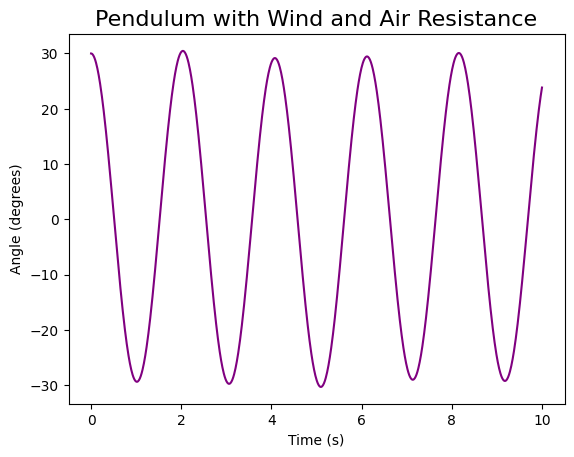

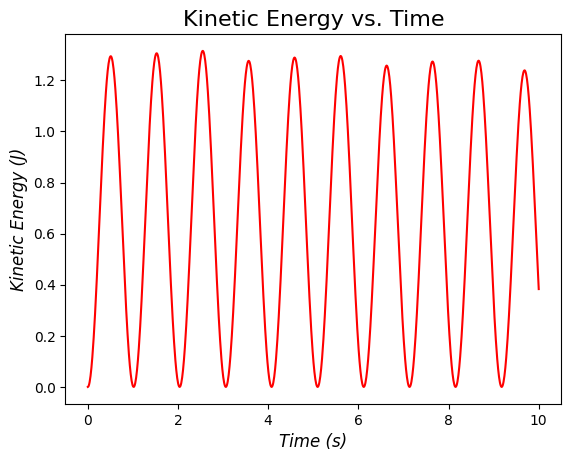

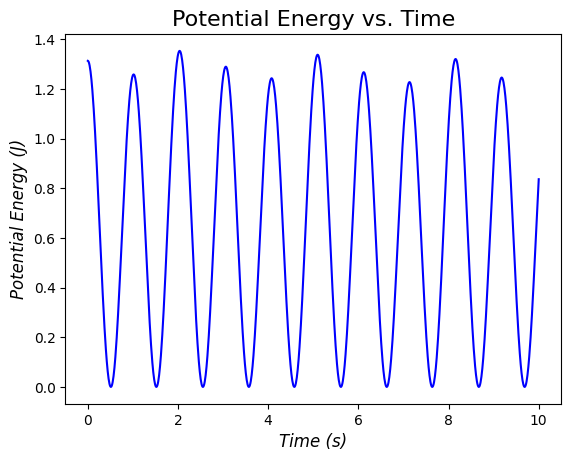

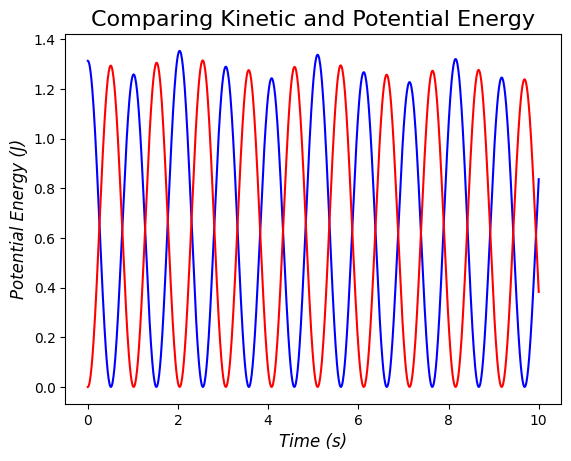

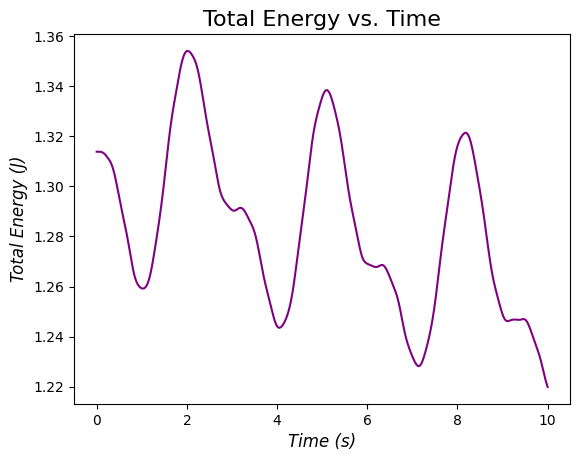

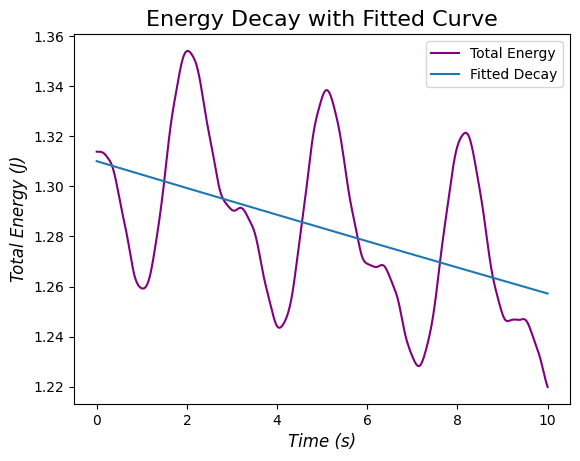

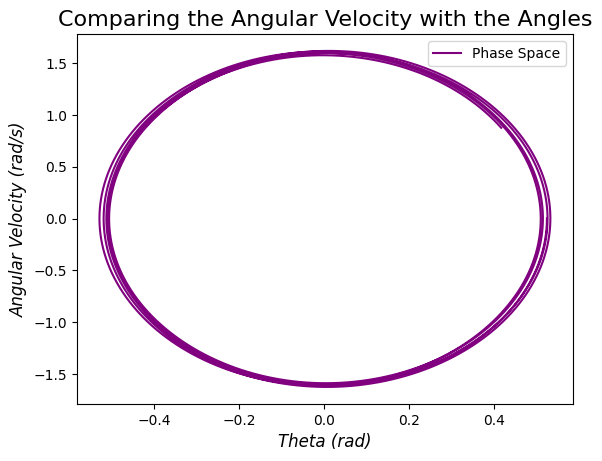

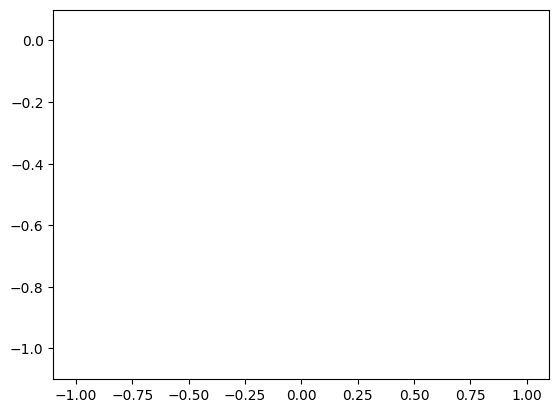

In [ ]:
# Importing modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import matplotlib.animation as animation

# Physical parameters
g = 9.80665 # m/s^2 at sea level
rho = 1.293 # kg/m^3 at sea level at 20 degrees Celcius
L = 1.0 # m length of the pendulum
m = 1.0 # kg mass of the pendulum bob
Cd = 0.45 # drag coefficient
A = 0.01 # m^2 cross-sectional area
F0 = 0.1 # N Force
frequency = 1.0 # angular frequency

# Function for the equations of motion
def gravity_wind(t, y):
    theta, angular_velocity = y

    # Wind force
    wind_f = (F0 * np.sin(frequency * t)) / (m * L)

    # Air Resistance
    air_resistance = -0.5 * rho * A * Cd * L * angular_velocity * abs(angular_velocity) / m

    # Angular velocity and acceleration
    dtheta_dt = angular_velocity
    domega_dt = -(g / L) * np.sin(theta) + wind_f + air_resistance

    return [dtheta_dt, domega_dt]


# Function to calculate total energy
def calc_energy(theta, angular_velocity):
    # Kinetic Energy
    kinetic = 0.5 * m * (L * angular_velocity)**2

    # Potential Energy
    potential = m * g * L * (1 - np.cos(theta))

    return kinetic, potential

# Get initial conditions from the user
theta0 = np.radians(float(input("Enter the initial angle in degrees (e.g., 30): ")))
angular_velocity0 = float(input("Enter the initial angular velocity (e.g., 0.0): "))
y0 = [theta0, angular_velocity0]

# Time span
t_span = (0, 10) # 10 seconds (simulation time)
t_eval = np.linspace(t_span[0], t_span[1], 1000) # Evaluating at 1000 time points

# Solve the ODEs (Runge Katta & solve_ivp methods)
solution = solve_ivp(gravity_wind, t_span, y0, t_eval = t_eval)
theta_values = solution.y[0] # array of the angles over time
angular_velocity_values = solution.y[1] # array of the angular velocities over time
time_values = solution.t # array of corresponding time points

# Calculate energies
kinetic =  []
potential = []
for theta, angular_velocity in zip(theta_values, angular_velocity_values):
    ke, pe = calc_energy(theta, angular_velocity)
    kinetic.append(ke)
    potential.append(pe)

# Calculate total energy
total_energy = [ke + pe for ke, pe in zip(kinetic, potential)]

# Energy decay
def decay_func(t, E0, lambd):
    return E0 * np.exp(-lambd * t)

popt, pcov = curve_fit(decay_func, time_values, total_energy, p0 = [total_energy[0], 0.1])

E0, lambd = popt

# Plotting the angle (theta) vs. time
plt.plot(time_values, np.degrees(theta_values), color = 'purple')
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Pendulum with Wind and Air Resistance", fontsize = 16)
plt.show()

# Plotting kinetic energy vs. time
plt.plot(time_values, kinetic, color = 'red')
plt.xlabel("Time (s)", fontsize = 12, style = "italic")
plt.ylabel("Kinetic Energy (J)", fontsize = 12, style = "italic")
plt.title("Kinetic Energy vs. Time", fontsize = 16)
plt.show()

# Plotting potential energy vs. time
plt.plot(time_values, potential, color = 'blue')
plt.xlabel("Time (s)", fontsize = 12, style = "italic")
plt.ylabel("Potential Energy (J)", fontsize = 12, style = "italic")
plt.title("Potential Energy vs. Time", fontsize = 16)
plt.show()

# Plotting the comparison of potential and kinetic energy
plt.plot(time_values, potential, color = 'blue')
plt.plot(time_values, kinetic, color = 'red')
plt.xlabel("Time (s)", fontsize = 12, style = "italic")
plt.ylabel("Potential Energy (J)", fontsize = 12, style = "italic")
plt.title("Comparing Kinetic and Potential Energy", fontsize = 16)
plt.show()

# Plotting total energy vs. time
plt.plot(time_values, total_energy, color = 'purple')
plt.xlabel("Time (s)", fontsize = 12, style = "italic")
plt.ylabel("Total Energy (J)", fontsize = 12, style = "italic")
plt.title("Total Energy vs. Time", fontsize = 16)
plt.show()

# Plotting the fitted curve
plt.plot(time_values, total_energy, label = "Total Energy", color = "purple")
plt.plot(time_values, decay_func(time_values, *popt), label = "Fitted Decay")
plt.xlabel("Time (s)", fontsize = 12, style = "italic")
plt.ylabel("Total Energy (J)", fontsize = 12, style = "italic")
plt.legend()
plt.title("Energy Decay with Fitted Curve", fontsize = 16)
plt.show()

plt.plot(theta_values, angular_velocity_values, label="Phase Space", color="purple")
plt.xlabel("Theta (rad)", fontsize = 12, style = "italic")
plt.ylabel("Angular Velocity (rad/s)", fontsize = 12, style = "italic")
plt.title("Comparing the Angular Velocity with the Angles", fontsize = 16)
plt.legend()
plt.show()

fig, ax = plt.subplots()
ax.set_xlim(-L - 0.1, L + 0.1)  # Setting limits slightly larger than L for visibility
ax.set_ylim(-L - 0.1, 0.1)
line, = ax.plot([], [], 'o-', lw=2)  # Pendulum rod and bob
trace, = ax.plot([], [], 'r.', markersize=1)  # Optional: trace of the bob's path
path_x, path_y = [], []  # For tracing the path of the bob

# Initialize the animation
def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

# Update function for animation
def update(frame):
    x = L * np.sin(theta_values[frame])
    y = -L * np.cos(theta_values[frame])
    path_x.append(x)
    path_y.append(y)
    line.set_data([0, x], [0, y])  # Update pendulum position
    trace.set_data(path_x, path_y)  # Update trace
    return line, trace

# Create the animation
ani = animation.FuncAnimation(
    fig, update, frames=len(t_eval), init_func=init, blit=True, interval=20
)

# Display the animation
plt.show()

ani.save('pendulum.mp4', writer='ffmpeg', fps=30)